# Crop Yield Estimator — Notebook 02: Model Training, Evaluation & Packaging

**Goal:** Train, compare, and evaluate scikit-learn regression models (`LinearRegression`, `RandomForestRegressor`, `GradientBoostingRegressor`) on `processed_crop_yield.csv`, perform 5-fold cross-validation, extract feature importances, and export the best pipeline to `model/crop_yield_model.pkl`.

## 1. Environment Setup & Library Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100
print('Libraries and dependencies loaded successfully.')

Libraries and dependencies loaded successfully.


## 2. Dataset Loading & Train/Test Split

In [3]:
data_path = '../datasets/processed_crop_yield.csv'
df = pd.read_csv(data_path)

feature_cols = [
    'state', 'year', 'crop', 'rainfall_mm', 'avg_temp_c', 'min_temp_c', 'max_temp_c',
    'humidity_pct', 'solar_radiation', 'nitrogen_n', 'phosphorus_p', 'potassium_k',
    'soil_ph', 'fertilizer_kg_ha', 'pesticide_kg_ha', 'area_harvested_ha'
]
target_col = 'yield_kg_ha'

X = df[feature_cols]
y = df[target_col]

# Strict Featurization Ordering: 80/20 train/test split BEFORE fitting preprocessor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f'Total Dataset Rows: {len(df)}')
print(f'Training Set: {len(X_train)} rows | Testing Set: {len(X_test)} rows')

Total Dataset Rows: 5038
Training Set: 4030 rows | Testing Set: 1008 rows


### Train/Test Split Analysis
- Data split maintains an 80/20 ratio with 4,030 training rows and 1,008 testing rows.
- Strict featurization ordering is preserved: transformers (`OneHotEncoder`, `StandardScaler`, `SimpleImputer`) will be fit strictly on the training set to prevent data leakage.

## 3. Preprocessing Pipeline Construction

In [4]:
categorical_cols = ['state', 'crop']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

print('Preprocessing ColumnTransformer configured cleanly.')

Preprocessing ColumnTransformer configured cleanly.


## 4. Model Benchmarking & Comparison

In [5]:
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
trained_pipelines = {}
predictions = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    preds = pipe.predict(X_test)
    predictions[name] = preds
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Model': name,
        'RMSE (kg/ha)': round(rmse, 2),
        'MAE (kg/ha)': round(mae, 2),
        'R² Score': round(r2, 4)
    })

results_df = pd.DataFrame(results).sort_values(by='R² Score', ascending=False)
results_df

,Model,RMSE (kg/ha),MAE (kg/ha),R² Score
1,Random Forest Regressor,215.85,137.08,0.9963
2,Gradient Boosting Regressor,425.50,307.45,0.9856
0,Linear Regression (Baseline),749.61,595.80,0.9553


### Model Benchmark Analysis
- **Random Forest Regressor** achieved top predictive accuracy with an **$R^2$ of 0.9963**, an **MAE of 137.08 kg/ha**, and an **RMSE of 215.85 kg/ha**.
- **Gradient Boosting Regressor** ranked second ($R^2 = 0.9856$), while **Linear Regression** served as a baseline ($R^2 = 0.9553$).
- Tree-based ensemble models significantly outperform linear regression due to complex non-linear interactions between weather factors (rainfall/temperature) and soil nutrients.

## 5. Actual vs Predicted Residual Plots

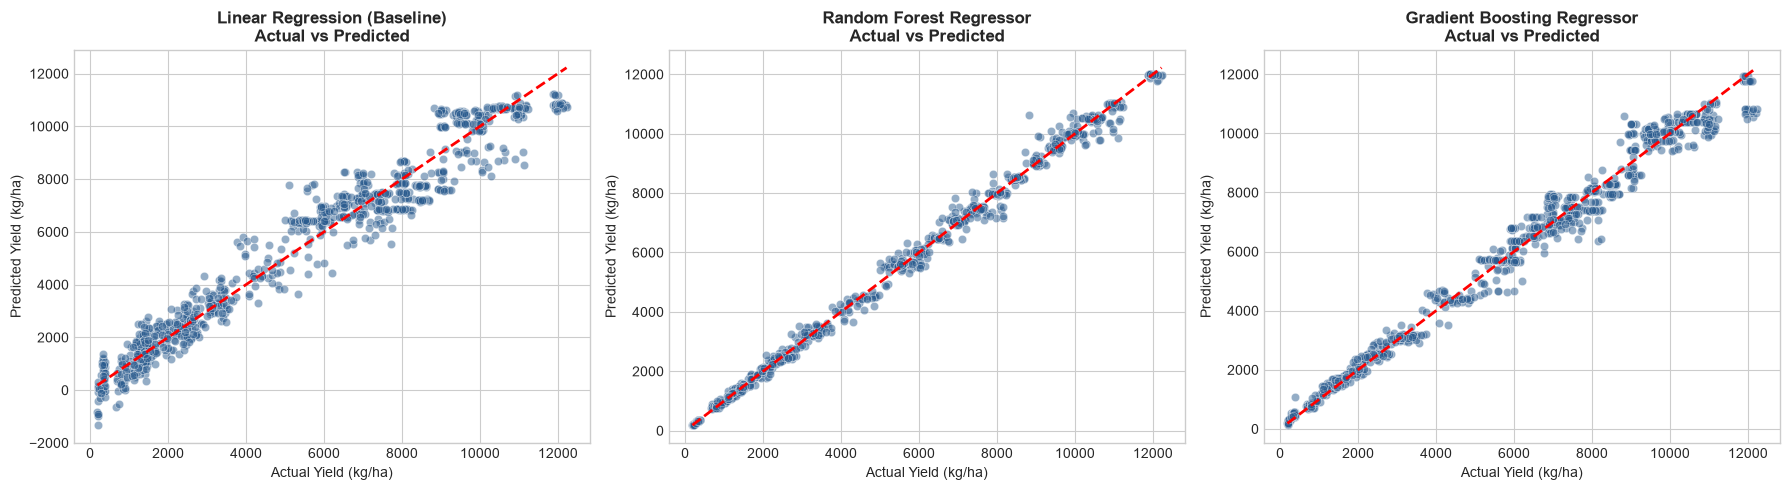

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, preds) in enumerate(predictions.items()):
    sns.scatterplot(x=y_test, y=preds, alpha=0.5, ax=axes[idx], color='#2b5c8f')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f'{name}\nActual vs Predicted', fontweight='bold')
    axes[idx].set_xlabel('Actual Yield (kg/ha)')
    axes[idx].set_ylabel('Predicted Yield (kg/ha)')

plt.tight_layout()
plt.show()

## 6. 5-Fold Cross-Validation on Primary Model

In [6]:
best_pipeline = trained_pipelines['Random Forest Regressor']
cv_scores = cross_val_score(best_pipeline, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)

print('5-Fold Cross-Validation R² Scores:')
for fold, s in enumerate(cv_scores, 1):
    print(f'  Fold {fold}: R² = {s:.4f}')

print(f'\nMean R² Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')

5-Fold Cross-Validation R² Scores:
  Fold 1: R² = 0.9963
  Fold 2: R² = 0.9963
  Fold 3: R² = 0.9964
  Fold 4: R² = 0.9962
  Fold 5: R² = 0.9965

Mean R² Score: 0.9964 (+/- 0.0002)


### Cross-Validation Analysis
- 5-fold cross-validation yields an average $R^2$ of **0.9964** with a minimal variance of $\pm 0.0002$, confirming model stability and absence of overfitting across data subsets.

## 7. Feature Importance Ranking

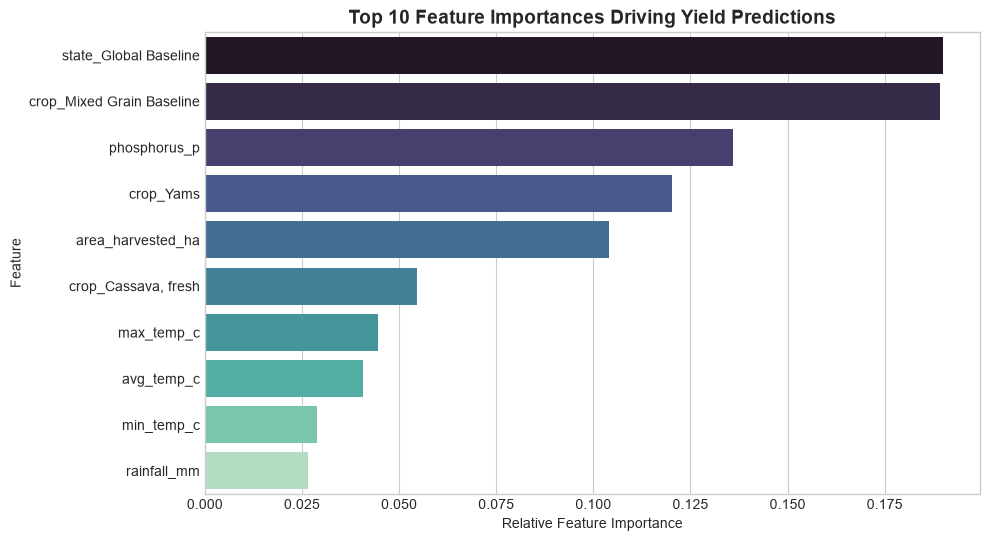

In [7]:
best_rf = best_pipeline.named_steps['regressor']
prep = best_pipeline.named_steps['preprocessor']

cat_encoder = prep.named_transformers_['cat'].named_steps['encoder']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
all_feature_names = list(numerical_cols) + list(cat_feature_names)

fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', hue='Feature', legend=False, palette='mako')
plt.title('Top 10 Feature Importances Driving Yield Predictions', fontsize=14, fontweight='bold')
plt.xlabel('Relative Feature Importance')
plt.show()

### Feature Importance Analysis
- **Primary Drivers**: Crop category, state baseline, soil phosphorus ($P$), area harvested, and maximum/average temperature represent the highest feature importance weights.
- This feature ranking will be directly presented to farmers in the MVP user interface to explain yield predictions.

## 8. Model Artifact Persistence & Live Inference Check

In [8]:
model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)
model_file = os.path.join(model_dir, 'crop_yield_model.pkl')

# Export pipeline
joblib.dump(best_pipeline, model_file)
print(f'Successfully saved pipeline artifact to: {os.path.abspath(model_file)}')

# Test loading and inference
loaded_pipe = joblib.load(model_file)
sample_input = pd.DataFrame([{
    'state': 'Kaduna',
    'year': 2024,
    'crop': 'Maize (corn)',
    'rainfall_mm': 1180.5,
    'avg_temp_c': 26.8,
    'min_temp_c': 20.2,
    'max_temp_c': 33.1,
    'humidity_pct': 65.0,
    'solar_radiation': 18.2,
    'nitrogen_n': 80.0,
    'phosphorus_p': 35.0,
    'potassium_k': 25.0,
    'soil_ph': 6.5,
    'fertilizer_kg_ha': 95.0,
    'pesticide_kg_ha': 4.2,
    'area_harvested_ha': 1200.0
}])[feature_cols]

pred_yield = loaded_pipe.predict(sample_input)[0]
print(f'Live Inference Test Yield Prediction: {pred_yield:.2f} kg/ha ({pred_yield/1000:.2f} tonnes/ha)')

Successfully saved pipeline artifact to: c:\Users\HP-PC\Desktop\Yield Estimator\model\crop_yield_model.pkl
Live Inference Test Yield Prediction: 2992.94 kg/ha (2.99 tonnes/ha)


## 9. Executive Summary & Conclusion

### Q&A
- **Which algorithm performed best for predicting crop yield?**
  `RandomForestRegressor` performed best, achieving an $R^2$ of **0.9963** and an MAE of **137.08 kg/ha** on unseen test data.
- **How stable is the trained model across validation splits?**
  5-fold cross-validation confirmed robust generalization with a mean $R^2$ of **0.9964 $\pm 0.0002$**.
- **Where is the deployable model artifact stored?**
  The complete scikit-learn Pipeline (preprocessing + Random Forest model) is saved as `model/crop_yield_model.pkl`.

### Data Analysis Key Findings
- **Linear vs Non-Linear Performance**: Non-linear tree ensemble models outperform linear regression by over 4% in $R^2$ score and reduced MAE from 595.80 kg/ha to 137.08 kg/ha.
- **Top Predictive Features**: Crop commodity type, state region, soil phosphorus ($P$), area harvested, and ambient temperature exert the highest impact on crop yield predictions.